In [1]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from tqdm import tqdm
from torchmetrics.functional import structural_similarity_index_measure

In [2]:
class MVTecLOCODataset(Dataset):
    def __init__(self, root_dir, split='train', anomaly_type='logical_anomalies', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []  # 0 for normal, 1 for anomaly

        if split == 'train':
            # Load 'good' images for training
            good_dir = os.path.join(root_dir, 'train', 'good')
            self._load_images_from_folder(good_dir, label=0)
        elif split == 'test':
            # Load 'good' and specified anomalies for testing
            good_dir = os.path.join(root_dir, 'test', 'good')
            anomaly_dir = os.path.join(root_dir, 'test', anomaly_type)
            self._load_images_from_folder(good_dir, label=0)
            self._load_images_from_folder(anomaly_dir, label=1)
        else:
            raise ValueError(f"Invalid split: {split}")

    def _load_images_from_folder(self, folder, label):
        if not os.path.isdir(folder):
            print(f"Folder {folder} is missing!")
            return
        for root, _, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, file)
                    self.image_paths.append(img_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label, img_path

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size[0] // patch_size) * (img_size[1] // patch_size)
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.position_embeddings = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))

    def forward(self, x):
        x = self.proj(x)  # Shape: (batch_size, embed_dim, n_patches_h, n_patches_w)
        x = x.flatten(2)  # Shape: (batch_size, embed_dim, n_patches)
        x = x.transpose(1, 2)  # Shape: (batch_size, n_patches, embed_dim)
        x = x + self.position_embeddings
        return x

In [4]:
class ViTEncoder(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim, depth, num_heads):
        super(ViTEncoder, self).__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.embed_dim = embed_dim
        self.n_patches = self.patch_embedding.n_patches
        self.fc_mu = nn.Linear(self.n_patches * embed_dim, embed_dim)
        self.fc_logvar = nn.Linear(self.n_patches * embed_dim, embed_dim)

    def forward(self, x):
        x = self.patch_embedding(x)  # (batch_size, n_patches, embed_dim)
        #x = x.transpose(0, 1)  # (n_patches, batch_size, embed_dim)
        x = self.transformer_encoder(x)  # (n_patches, batch_size, embed_dim)
        #x = x.transpose(0, 1)  # (batch_size, n_patches, embed_dim)
        x = x.flatten(1)  # (batch_size, n_patches * embed_dim)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [5]:
class ConvDecoder(nn.Module):
    def __init__(self, img_size, in_channels, embed_dim):
        super(ConvDecoder, self).__init__()
        self.img_size = img_size  # Store the target image size
        self.embed_dim = embed_dim
        self.init_size = (img_size[0] // 16, img_size[1] // 16)
        self.fc = nn.Linear(embed_dim, 512 * self.init_size[0] * self.init_size[1])
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, in_channels, kernel_size=4, stride=2, padding=1),
            #nn.Sigmoid()
            nn.Tanh()
        )

    def forward(self, z):
        batch_size = z.size(0)
        x = self.fc(z)
        x = x.view(batch_size, 512, self.init_size[0], self.init_size[1])
        x = self.decoder(x)
        # Resize to match the input image dimensions
        x = nn.functional.interpolate(x, size=self.img_size, mode='bilinear', align_corners=False)
        return x

In [6]:
class ViTVAE(nn.Module):
    def __init__(self, img_size=(1100, 1600), patch_size=64, in_channels=3, embed_dim=512, depth=6, num_heads=8):
        super(ViTVAE, self).__init__()
        self.encoder = ViTEncoder(img_size, patch_size, in_channels, embed_dim, depth, num_heads)
        self.decoder = ConvDecoder(img_size, in_channels, embed_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score
#def evaluate(model, dataloader, criterion, device):
def evaluate(model, dataloader, kld_weight, device):
    model.eval()
    total_loss = 0.0
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for images, labels, _ in dataloader:
            images = images.to(device)
            outputs, mu, logvar = model(images)
            #recon_loss = criterion(outputs, images)
            #recon_loss = recon_loss.view(recon_loss.size(0), -1).mean(dim=1)  # Per-image loss
            outputs_ssim = (outputs + 1) / 2
            images_ssim = (images + 1) / 2

            ssim_loss = 1 - structural_similarity_index_measure(outputs_ssim, images_ssim, data_range=1.0)            
            kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            #anomaly_scores = recon_loss + kld_loss * 1e-3  # Adjust weight as needed
            anomaly_scores = ssim_loss + kld_loss * kld_weight  # Adjust weight as needed
            all_scores.extend(anomaly_scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            #total_loss += recon_loss.sum().item()
            total_loss += ssim_loss.sum().item()
    avg_loss = total_loss / len(dataloader.dataset)
    # Compute AUROC
    auroc = roc_auc_score(all_labels, all_scores)
    return avg_loss, auroc

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_reconstruction(model, dataloader, device):
    model.eval()
    images, labels, paths = next(iter(dataloader))
    images = images.to(device)
    with torch.no_grad():
        reconstructed, _, _ = model(images)
    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    reconstructed = reconstructed.cpu().numpy().transpose(0, 2, 3, 1)

    # Rescale images from [-1, 1] to [0, 1]
    images = (images + 1) / 2.0
    reconstructed = (reconstructed + 1) / 2.0

    # Ensure the pixel values are clipped between 0 and 1
    images = np.clip(images, 0, 1)
    reconstructed = np.clip(reconstructed, 0, 1)

    # Determine the number of images to display
    num_images = min(len(images), 5)

    # Adjust the axes array to handle cases where num_images < 5
    fig, axes = plt.subplots(2, num_images, figsize=(3 * num_images, 6))

    # If num_images is 1, axes may not be a 2D array; adjust accordingly
    if num_images == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i in range(num_images):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i])
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

In [9]:
def kl_anneal_function(epoch, start_epoch, end_epoch):
    if epoch < start_epoch:
        return 0.0
    elif epoch > end_epoch:
        return 1.0
    else:
        return (epoch - start_epoch) / (end_epoch - start_epoch)

In [10]:
#def train(model, dataloader, optimizer, criterion, device):
#def train(model, dataloader, optimizer, device):
def train(model, dataloader, optimizer, kld_weight, device):
    model.train()
    running_loss = 0.0
    running_recon_loss = 0.0
    running_kld_loss = 0.0

    # Create a progress bar using tqdm
    pbar = tqdm(dataloader, desc='Training', leave=False)
    
    for images, _, _ in pbar:
        images = images.to(device)
        optimizer.zero_grad()
        outputs, mu, logvar = model(images)
        
        #####################################################################
        #recon_loss = criterion(outputs, images).mean()
        #kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        #loss = recon_loss + kld_loss * 1e-3  # Adjusted KL divergence weight
        ######################################################################
        outputs_ssim = (outputs + 1) / 2
        images_ssim = (images + 1) / 2
        
        ssim_loss = 1 - structural_similarity_index_measure(outputs_ssim, images_ssim, data_range=1.0)
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = ssim_loss + kld_loss * kld_weight  # Adjust KLD weight if necessary

        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        #running_recon_loss += recon_loss.item()
        running_recon_loss += ssim_loss.item()
        running_kld_loss += kld_loss.item()

        # Update progress bar with the current loss values
        pbar.set_postfix({
            'Loss': f'{loss.item():.6f}',
            #'Recon Loss': f'{recon_loss.item():.6f}',
            'Recon Loss': f'{ssim_loss.item():.6f}',
            'KL Loss': f'{kld_loss.item():.6f}'
        })

    avg_loss = running_loss / len(dataloader)
    avg_recon_loss = running_recon_loss / len(dataloader)
    avg_kld_loss = running_kld_loss / len(dataloader)
    return avg_loss, avg_recon_loss, avg_kld_loss

Epoch 356/500, Train Loss: 0.054964, Recon Loss: 0.053724, KL Loss: 12.396161, Test Loss: 0.054155, AUROC: 0.7260


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 357/500, Train Loss: 0.054963, Recon Loss: 0.053728, KL Loss: 12.343583, Test Loss: 0.053804, AUROC: 0.7164


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 358/500, Train Loss: 0.054930, Recon Loss: 0.053699, KL Loss: 12.313356, Test Loss: 0.052274, AUROC: 0.7099


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 359/500, Train Loss: 0.055202, Recon Loss: 0.053972, KL Loss: 12.302859, Test Loss: 0.053316, AUROC: 0.7331


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 360/500, Train Loss: 0.055169, Recon Loss: 0.053941, KL Loss: 12.280145, Test Loss: 0.053177, AUROC: 0.7093


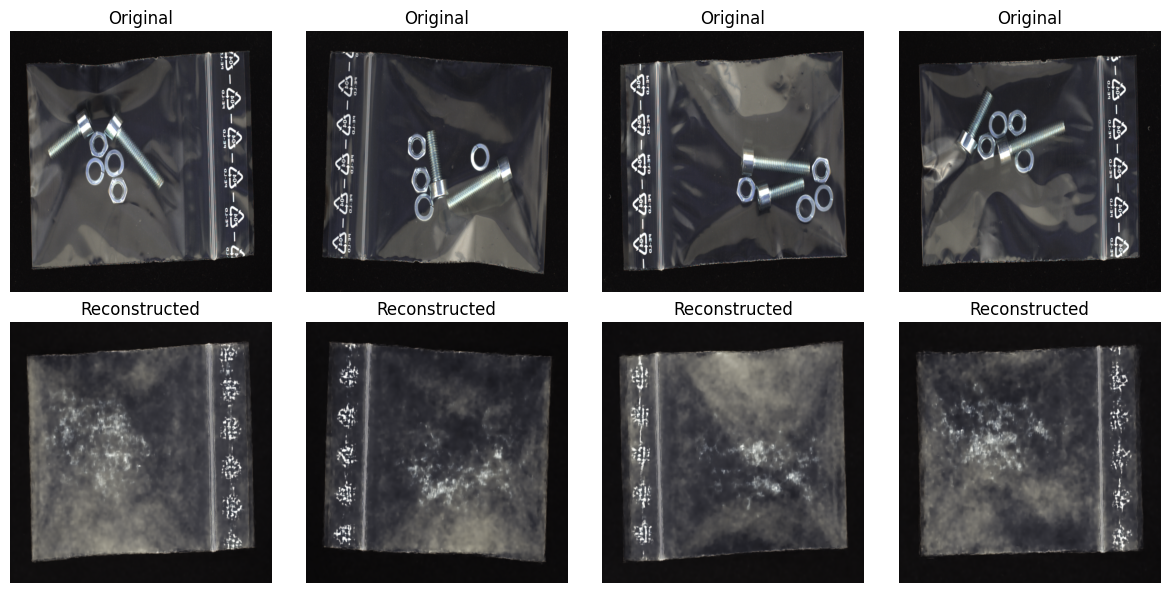

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 361/500, Train Loss: 0.054509, Recon Loss: 0.053287, KL Loss: 12.218763, Test Loss: 0.053238, AUROC: 0.7113


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 362/500, Train Loss: 0.054328, Recon Loss: 0.053113, KL Loss: 12.152751, Test Loss: 0.054469, AUROC: 0.7336


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 368/500, Train Loss: 0.054683, Recon Loss: 0.053465, KL Loss: 12.179017, Test Loss: 0.054393, AUROC: 0.7375


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 369/500, Train Loss: 0.055171, Recon Loss: 0.053956, KL Loss: 12.153747, Test Loss: 0.054942, AUROC: 0.7306


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 370/500, Train Loss: 0.054657, Recon Loss: 0.053441, KL Loss: 12.158078, Test Loss: 0.053896, AUROC: 0.7321


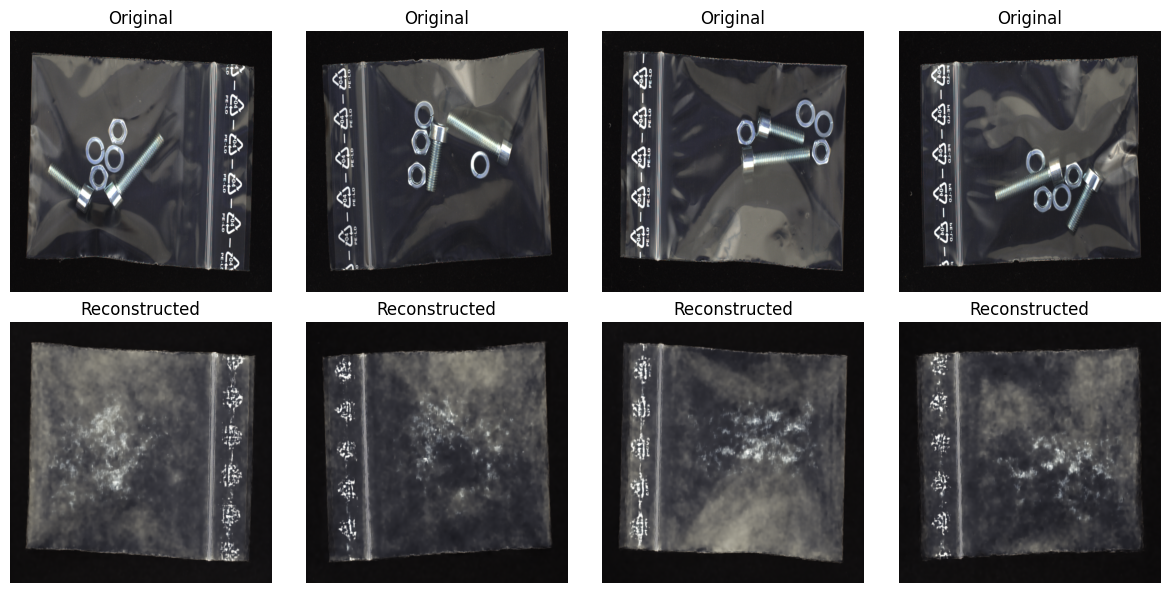

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 371/500, Train Loss: 0.053767, Recon Loss: 0.052566, KL Loss: 12.010813, Test Loss: 0.053962, AUROC: 0.7211


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 372/500, Train Loss: 0.053551, Recon Loss: 0.052358, KL Loss: 11.930123, Test Loss: 0.053957, AUROC: 0.7144


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 378/500, Train Loss: 0.053754, Recon Loss: 0.052579, KL Loss: 11.741650, Test Loss: 0.053482, AUROC: 0.7256


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 379/500, Train Loss: 0.053505, Recon Loss: 0.052326, KL Loss: 11.787848, Test Loss: 0.052666, AUROC: 0.7377


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 380/500, Train Loss: 0.053227, Recon Loss: 0.052055, KL Loss: 11.714557, Test Loss: 0.052143, AUROC: 0.7110


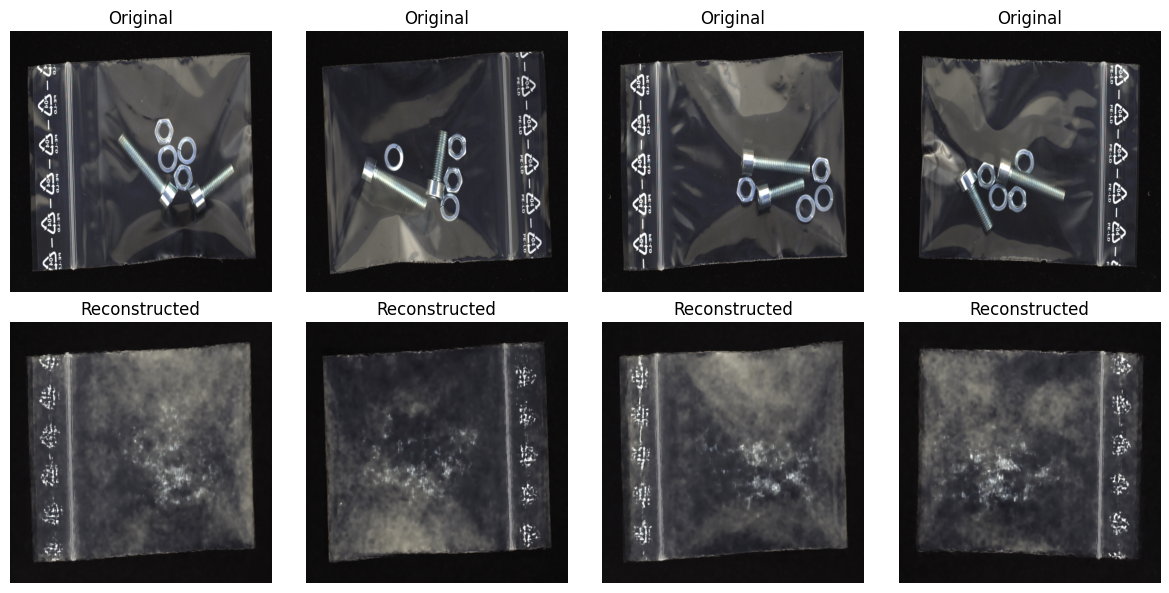

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 381/500, Train Loss: 0.052940, Recon Loss: 0.051767, KL Loss: 11.733266, Test Loss: 0.053104, AUROC: 0.7394


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 382/500, Train Loss: 0.053035, Recon Loss: 0.051866, KL Loss: 11.691868, Test Loss: 0.053477, AUROC: 0.7338


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 388/500, Train Loss: 0.052469, Recon Loss: 0.051322, KL Loss: 11.472178, Test Loss: 0.054729, AUROC: 0.7189


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 389/500, Train Loss: 0.052673, Recon Loss: 0.051535, KL Loss: 11.386256, Test Loss: 0.052537, AUROC: 0.7114


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 390/500, Train Loss: 0.052764, Recon Loss: 0.051613, KL Loss: 11.517159, Test Loss: 0.054172, AUROC: 0.7278


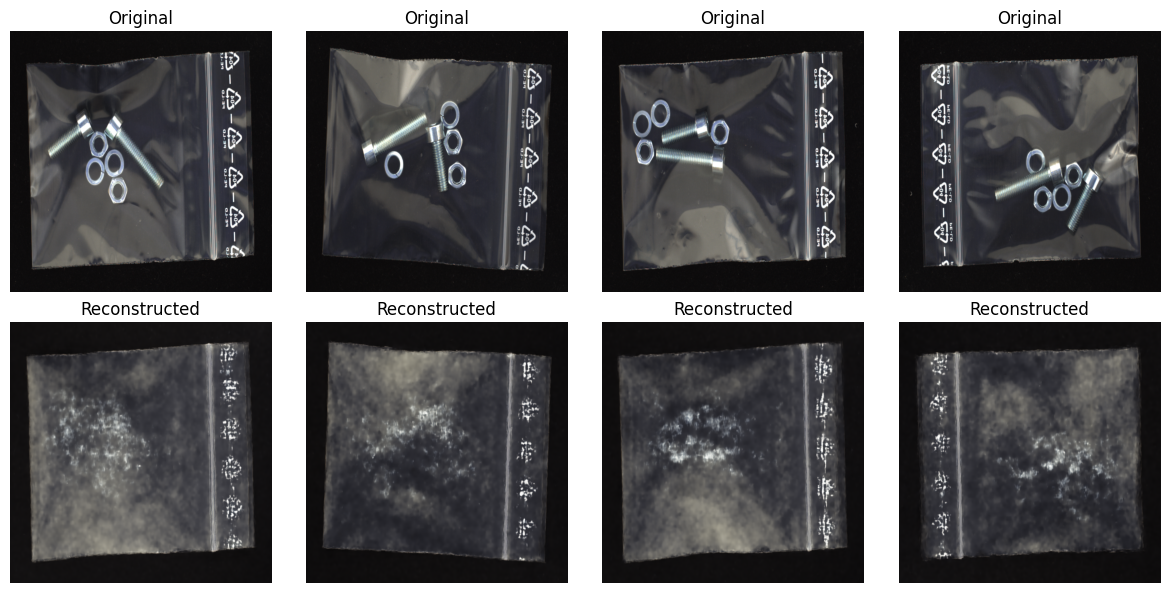

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 391/500, Train Loss: 0.052405, Recon Loss: 0.051257, KL Loss: 11.483579, Test Loss: 0.053447, AUROC: 0.7242


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 392/500, Train Loss: 0.052465, Recon Loss: 0.051320, KL Loss: 11.449936, Test Loss: 0.053013, AUROC: 0.7255


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 398/500, Train Loss: 0.051719, Recon Loss: 0.050589, KL Loss: 11.297464, Test Loss: 0.055126, AUROC: 0.7353


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 399/500, Train Loss: 0.051795, Recon Loss: 0.050672, KL Loss: 11.221997, Test Loss: 0.052841, AUROC: 0.7229


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 400/500, Train Loss: 0.052007, Recon Loss: 0.050878, KL Loss: 11.294505, Test Loss: 0.054559, AUROC: 0.7345


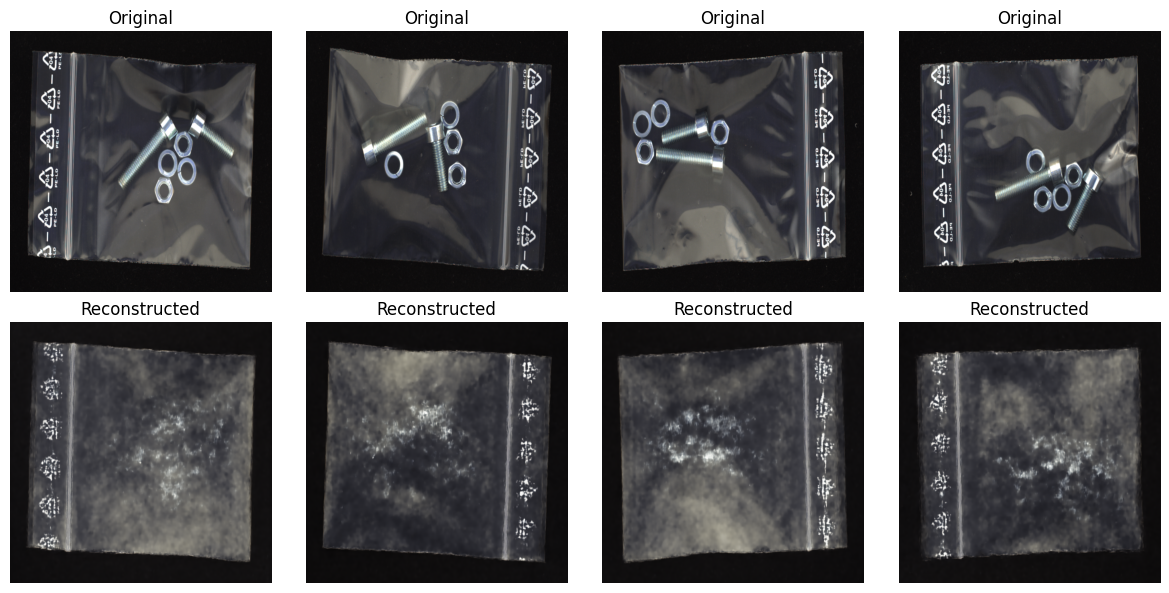

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 401/500, Train Loss: 0.051949, Recon Loss: 0.050817, KL Loss: 11.312931, Test Loss: 0.053210, AUROC: 0.7084


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 402/500, Train Loss: 0.051513, Recon Loss: 0.050391, KL Loss: 11.218365, Test Loss: 0.051671, AUROC: 0.7138


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 408/500, Train Loss: 0.052243, Recon Loss: 0.051127, KL Loss: 11.156841, Test Loss: 0.053789, AUROC: 0.7323


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 409/500, Train Loss: 0.051755, Recon Loss: 0.050635, KL Loss: 11.201642, Test Loss: 0.054015, AUROC: 0.7364


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 410/500, Train Loss: 0.051639, Recon Loss: 0.050532, KL Loss: 11.065399, Test Loss: 0.052883, AUROC: 0.7363


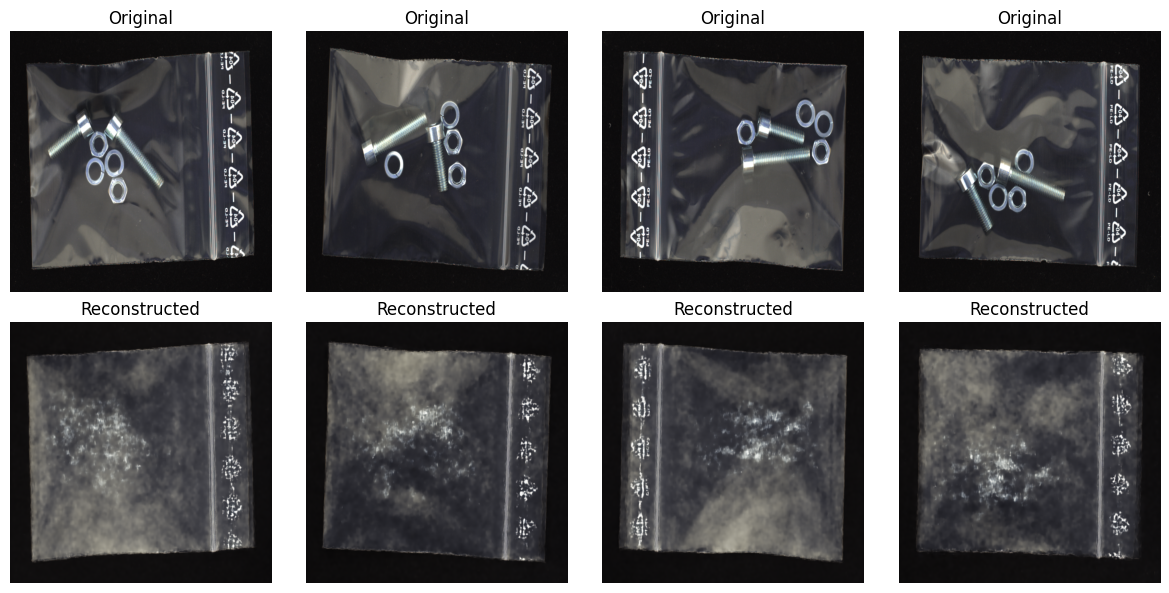

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 411/500, Train Loss: 0.051919, Recon Loss: 0.050799, KL Loss: 11.207522, Test Loss: 0.053019, AUROC: 0.7481


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 412/500, Train Loss: 0.051801, Recon Loss: 0.050687, KL Loss: 11.143764, Test Loss: 0.052834, AUROC: 0.7353


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 418/500, Train Loss: 0.050588, Recon Loss: 0.049493, KL Loss: 10.950222, Test Loss: 0.054393, AUROC: 0.7548


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 419/500, Train Loss: 0.050346, Recon Loss: 0.049249, KL Loss: 10.967776, Test Loss: 0.054966, AUROC: 0.7555


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 420/500, Train Loss: 0.050324, Recon Loss: 0.049234, KL Loss: 10.896804, Test Loss: 0.052233, AUROC: 0.7379


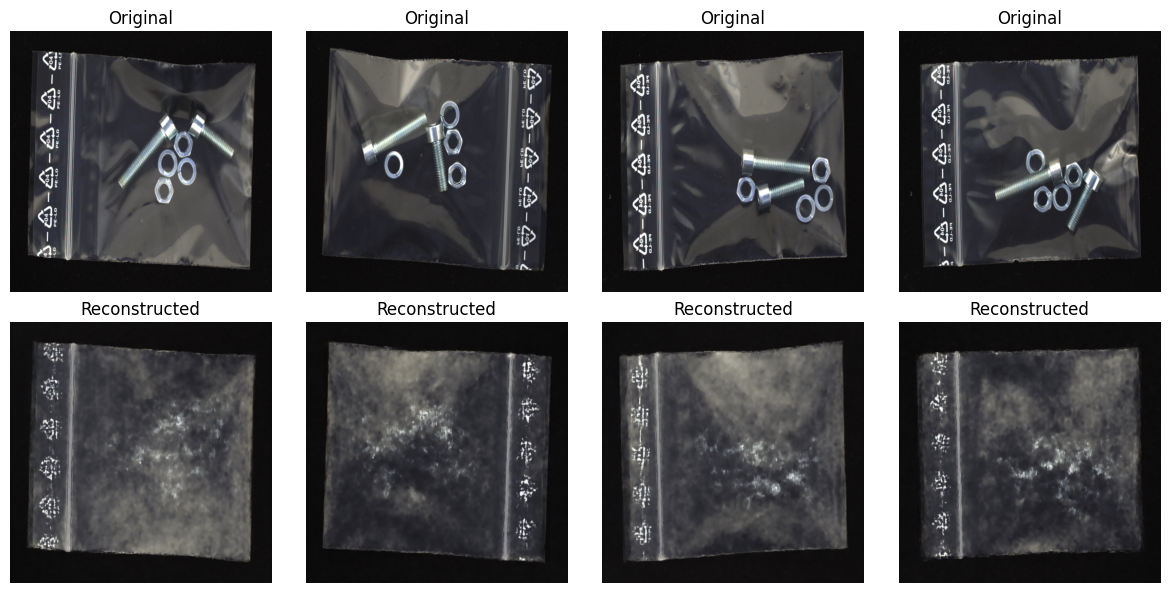

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 421/500, Train Loss: 0.050844, Recon Loss: 0.049750, KL Loss: 10.943083, Test Loss: 0.053914, AUROC: 0.7524


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 422/500, Train Loss: 0.050572, Recon Loss: 0.049474, KL Loss: 10.980366, Test Loss: 0.054132, AUROC: 0.7535


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 428/500, Train Loss: 0.049770, Recon Loss: 0.048713, KL Loss: 10.570411, Test Loss: 0.054066, AUROC: 0.7694


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 429/500, Train Loss: 0.049811, Recon Loss: 0.048748, KL Loss: 10.623138, Test Loss: 0.053739, AUROC: 0.7305


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 430/500, Train Loss: 0.049303, Recon Loss: 0.048240, KL Loss: 10.629462, Test Loss: 0.054259, AUROC: 0.7382


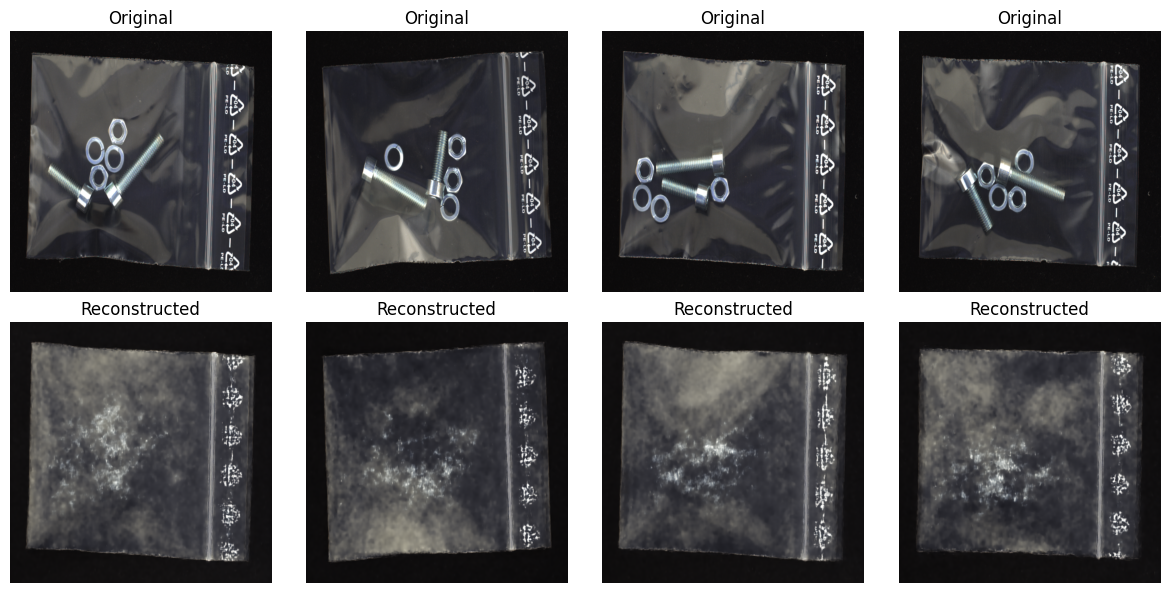

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 431/500, Train Loss: 0.049018, Recon Loss: 0.047973, KL Loss: 10.449926, Test Loss: 0.054093, AUROC: 0.7583


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 432/500, Train Loss: 0.049165, Recon Loss: 0.048123, KL Loss: 10.423111, Test Loss: 0.053071, AUROC: 0.7285


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 438/500, Train Loss: 0.048977, Recon Loss: 0.047938, KL Loss: 10.389223, Test Loss: 0.054585, AUROC: 0.7478


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 439/500, Train Loss: 0.049347, Recon Loss: 0.048307, KL Loss: 10.406945, Test Loss: 0.053442, AUROC: 0.7521


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


KeyboardInterrupt: 

In [11]:
def main():
    # Hyperparameters
    img_size = (1024, 1024)
    patch_size = 64
    in_channels = 3
    embed_dim = 128
    depth = 6
    num_heads = 8
    batch_size = 4  # Adjust based on GPU memory
    num_epochs = 500  # Number of additional epochs you want to train
    learning_rate = 1e-4
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/screw_bag"
    
    transform = transforms.Compose([
        transforms.Resize(img_size),
        #transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        #transforms.RandomRotation(15),
        #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])
    
    # Datasets and Dataloaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model, Loss, Optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ViTVAE(img_size=img_size, patch_size=patch_size, in_channels=in_channels,
                   embed_dim=embed_dim, depth=depth, num_heads=num_heads).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    #criterion = nn.MSELoss(reduction='none')  # Compute per-pixel loss

    # Load the saved model and optimizer states
    checkpoint_path = '/home/hafiz/my_thesis/seg_recons/VitVae2_checkpoint_epoch_0.pth'
    if os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from '{checkpoint_path}'")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Load model state
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Load optimizer state
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        # Set the starting epoch to the saved epoch
        start_epoch = checkpoint['epoch'] + 1  # Continue training from the next epoch
        print(f"Resuming training from epoch {start_epoch}.")
    else:
        print(f"No checkpoint found at '{checkpoint_path}'")
        start_epoch = 0  # If no checkpoint is found, start from epoch 0

    # Training Loop
    for epoch in range(start_epoch, start_epoch + num_epochs):
        kld_weight = kl_anneal_function(epoch, start_epoch, start_epoch + num_epochs // 2) * 1e-4
        # train_loss, train_recon_loss, train_kld_loss = train(
        #     model, train_loader, optimizer, criterion, device
        # )
        # test_loss, auroc = evaluate(model, test_loader, criterion, device)

        train_loss, train_recon_loss, train_kld_loss = train(
            model, train_loader, optimizer, kld_weight, device
        )
        test_loss, auroc = evaluate(model, test_loader, kld_weight, device)

        print(
            f"Epoch {epoch+1}/{start_epoch + num_epochs}, "
            f"Train Loss: {train_loss:.6f}, Recon Loss: {train_recon_loss:.6f}, KL Loss: {train_kld_loss:.6f}, "
            f"Test Loss: {test_loss:.6f}, AUROC: {auroc:.4f}"
        )
        if (epoch + 1) % 10 == 0:
            visualize_reconstruction(model, test_loader, device)
        if (epoch + 1) % 25 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, f'VitVae2_ssim_checkpoint_epoch_{epoch+1}.pth')
            
    # Save the model after each epoch (optional)
    torch.save(model.state_dict(), f'VitVae2_ssim_epoch_{epoch+1}.pth')
    torch.save(optimizer.state_dict(), f'VitVae2_ssim_optim_epoch_{epoch+1}.pth')

if __name__ == "__main__":
    main()